# Preprocessing Data (NO2 Surabaya)

In [1]:
import pandas as pd

# 1️⃣ Baca file hasil Copernicus
new_df = pd.read_csv("no2_results_surabaya/timeseries.csv")

# 2️⃣ Urutkan berdasarkan tanggal dan reset index
new_df = new_df.sort_values(by="date").reset_index(drop=True)

# 3️⃣ Ubah kolom 'date' jadi tipe datetime (tanpa waktu)
new_df["date"] = pd.to_datetime(new_df["date"]).dt.date

# 4️⃣ Tampilkan hasil
new_df


,date,feature_index,NO2
0,2020-05-31,0,NaN
1,2020-06-01,0,NaN
2,2020-06-02,0,NaN
3,2020-06-03,0,0.000016
4,2020-06-04,0,0.000028
...,...,...,...
390,2021-06-25,0,0.000024
391,2021-06-26,0,0.000033
392,2021-06-27,0,0.000019
393,2021-06-28,0,NaN


C:\Users\Jordan\AppData\Local\Temp\ipykernel_23852\1537943278.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",


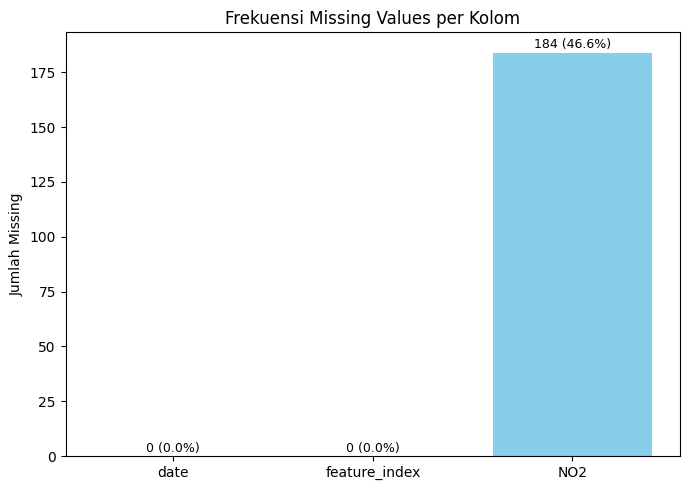


Tabel Missing Value:
               Missing Count  Missing Percent (%)
date                       0                 0.00
feature_index              0                 0.00
NO2                      184                46.58


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1️⃣ Baca data (sesuaikan dengan file kamu)
new_df = pd.read_csv("no2_results_surabaya/timeseries.csv")

# 2️⃣ Urutkan tanggal
new_df = new_df.sort_values(by="date").reset_index(drop=True)
new_df["date"] = pd.to_datetime(new_df["date"]).dt.date

# 3️⃣ Hitung missing value per kolom
missing_count = new_df.isnull().sum()
missing_percent = (missing_count / len(new_df)) * 100

# 4️⃣ Buat visualisasi
fig, ax = plt.subplots(figsize=(7,5))
bars = ax.bar(missing_count.index, missing_count, color="skyblue")

ax.set_title("Frekuensi Missing Values per Kolom")
ax.set_ylabel("Jumlah Missing")

for i, v in enumerate(missing_count):
    ax.text(i, v + 0.5, f"{v} ({missing_percent[i]:.1f}%)",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 5️⃣ Buat tabel ringkasan
missing_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent (%)": missing_percent.round(2)
})

print("\nTabel Missing Value:")
print(missing_table)


In [3]:
import pandas as pd

# 1️⃣ Baca file hasil Copernicus
new_df = pd.read_csv("no2_results_surabaya/timeseries.csv")

# 2️⃣ Pastikan kolom tanggal dalam format datetime
new_df["date"] = pd.to_datetime(new_df["date"]).dt.date

# 3️⃣ Ubah jadi Series agar bisa interpolasi berdasarkan tanggal
new_df = pd.Series(new_df["NO2"].values, index=new_df["date"], name="NO2")

# 4️⃣ Lakukan interpolasi linear dan backward fill untuk sisa missing di awal
new_df = new_df.interpolate(method="linear").bfill()

# 5️⃣ Ubah kembali ke DataFrame
new_df = pd.DataFrame(new_df).reset_index()

# 6️⃣ Simpan hasil ke CSV
new_df.to_csv("no2_results_surabaya/timeseries_cleaned.csv", index=False)

# 7️⃣ Tampilkan hasil
print("Data setelah missing value diperbaiki:")
print(new_df.head())
print("\nDisimpan ke: no2_results_surabaya/timeseries_cleaned.csv")


Data setelah missing value diperbaiki:
         date       NO2
0  2020-06-15  0.000045
1  2020-06-14  0.000040
2  2020-06-13  0.000035
3  2020-06-16  0.000023
4  2020-06-17  0.000029

Disimpan ke: no2_results_surabaya/timeseries_cleaned.csv


In [4]:
missing_count = new_df.isnull().sum()
missing_percent = (missing_count / len(new_df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

missing_table

,Missing Count,Missing Percent (%)
date,0,0.0
NO2,0,0.0


Setelah dilakukan proses interpolasi linier pada kolom NO₂, hasil pemeriksaan ulang memperlihatkan bahwa seluruh nilai yang sebelumnya hilang telah berhasil terisi sepenuhnya.

Dengan demikian, dataset kini telah bebas dari missing value dan siap digunakan pada tahap berikutnya, yaitu pemodelan prediksi konsentrasi NO₂ menggunakan metode K-Nearest Neighbors (KNN) Regression.

## 1.2 Konversi ke Supervised Learning**
Pada proyek ini, dilakukan proses konversi data time series menjadi format supervised learning menggunakan Python. Tujuan dari konversi ini adalah agar data time series dapat dimanfaatkan untuk model prediksi berbasis machine learning seperti regresi maupun neural network.

Secara umum, data time series hanya memuat nilai berdasarkan urutan waktu, sedangkan supervised learning membutuhkan pasangan input (X) dan output (y). Oleh karena itu, konversi dilakukan dengan menggeser data pada waktu sebelumnya untuk dijadikan sebagai fitur (lag features).

Dalam penerapan kali ini, saya melakukan eksperimen dengan menggunakan data dari 2 hingga 5 hari sebelumnya sebagai fitur input.


# Langkah - Langkah
# Menginisialisasi day 2 - 5

In [5]:
day2 = new_df
day3 = new_df
day4 = new_df
day5 = new_df

# Membuat data supervised menggunakan t1, t2

In [6]:
day2 = day2.drop(columns=['date'])
n = 2

for i in range(1, n + 1):
    names = f"t{i}"
    day2[names] = day2['NO2'].shift(i)

day2 = day2.dropna().reset_index(drop=True)
day2

,NO2,t1,t2
0,0.000035,0.000040,0.000045
1,0.000023,0.000035,0.000040
2,0.000029,0.000023,0.000035
3,0.000038,0.000029,0.000023
4,0.000027,0.000038,0.000029
...,...,...,...
388,0.000029,0.000024,0.000016
389,0.000033,0.000029,0.000024
390,0.000027,0.000033,0.000029
391,0.000023,0.000027,0.000033


# Membuat data supervised menggunakan t1, t2, t3

In [7]:
day3 = day3.drop(columns=['date'])
n = 3

for i in range(1, n + 1):
    names = f"t{i}"
    day3[names] = day3['NO2'].shift(i)

day3 = day3.dropna().reset_index(drop=True)
day3

,NO2,t1,t2,t3
0,0.000023,0.000035,0.000040,0.000045
1,0.000029,0.000023,0.000035,0.000040
2,0.000038,0.000029,0.000023,0.000035
3,0.000027,0.000038,0.000029,0.000023
4,0.000069,0.000027,0.000038,0.000029
...,...,...,...,...
387,0.000029,0.000024,0.000016,0.000029
388,0.000033,0.000029,0.000024,0.000016
389,0.000027,0.000033,0.000029,0.000024
390,0.000023,0.000027,0.000033,0.000029


# Membuat data supervised menggunakan t1, t2, t3, t4

In [8]:
day4 = day4.drop(columns=['date'])
n = 4

for i in range(1, n + 1):
    names = f"t{i}"
    day4[names] = day4['NO2'].shift(i)

day4 = day4.dropna().reset_index(drop=True)
day4

,NO2,t1,t2,t3,t4
0,0.000029,0.000023,0.000035,0.000040,0.000045
1,0.000038,0.000029,0.000023,0.000035,0.000040
2,0.000027,0.000038,0.000029,0.000023,0.000035
3,0.000069,0.000027,0.000038,0.000029,0.000023
4,0.000031,0.000069,0.000027,0.000038,0.000029
...,...,...,...,...,...
386,0.000029,0.000024,0.000016,0.000029,0.000052
387,0.000033,0.000029,0.000024,0.000016,0.000029
388,0.000027,0.000033,0.000029,0.000024,0.000016
389,0.000023,0.000027,0.000033,0.000029,0.000024


# Membuat data supervised menggunakan t1, t2, t3, t4, t5

In [9]:
day5 = day5.drop(columns=['date'])
# new_df
n = 5

for i in range(1, n + 1):
    names = f"t{i}"
    day5[names] = day5['NO2'].shift(i)

day5 = day5.dropna().reset_index(drop=True)
day5

,NO2,t1,t2,t3,t4,t5
0,0.000038,0.000029,0.000023,0.000035,0.000040,0.000045
1,0.000027,0.000038,0.000029,0.000023,0.000035,0.000040
2,0.000069,0.000027,0.000038,0.000029,0.000023,0.000035
3,0.000031,0.000069,0.000027,0.000038,0.000029,0.000023
4,0.000019,0.000031,0.000069,0.000027,0.000038,0.000029
...,...,...,...,...,...,...
385,0.000029,0.000024,0.000016,0.000029,0.000052,0.000055
386,0.000033,0.000029,0.000024,0.000016,0.000029,0.000052
387,0.000027,0.000033,0.000029,0.000024,0.000016,0.000029
388,0.000023,0.000027,0.000033,0.000029,0.000024,0.000016
